In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [2]:
# Load data splits
with open('../data/processed/data_splits.pkl', 'rb') as f:
    data = pickle.load(f)

X_test = data['X_test']
y_test = data['y_test']
le = data['label_encoder']

# Load models
with open('../data/processed/lr_model.pkl', 'rb') as f:
    lr_model = pickle.load(f)

with open('../data/processed/mnb_model.pkl', 'rb') as f:
    mnb_model = pickle.load(f)

# Prediksi
y_pred_lr = lr_model.predict(X_test)
y_pred_mnb = mnb_model.predict(X_test)

print(f"Classes: {le.classes_}")

Classes: ['Critical' 'Low' 'Medium']


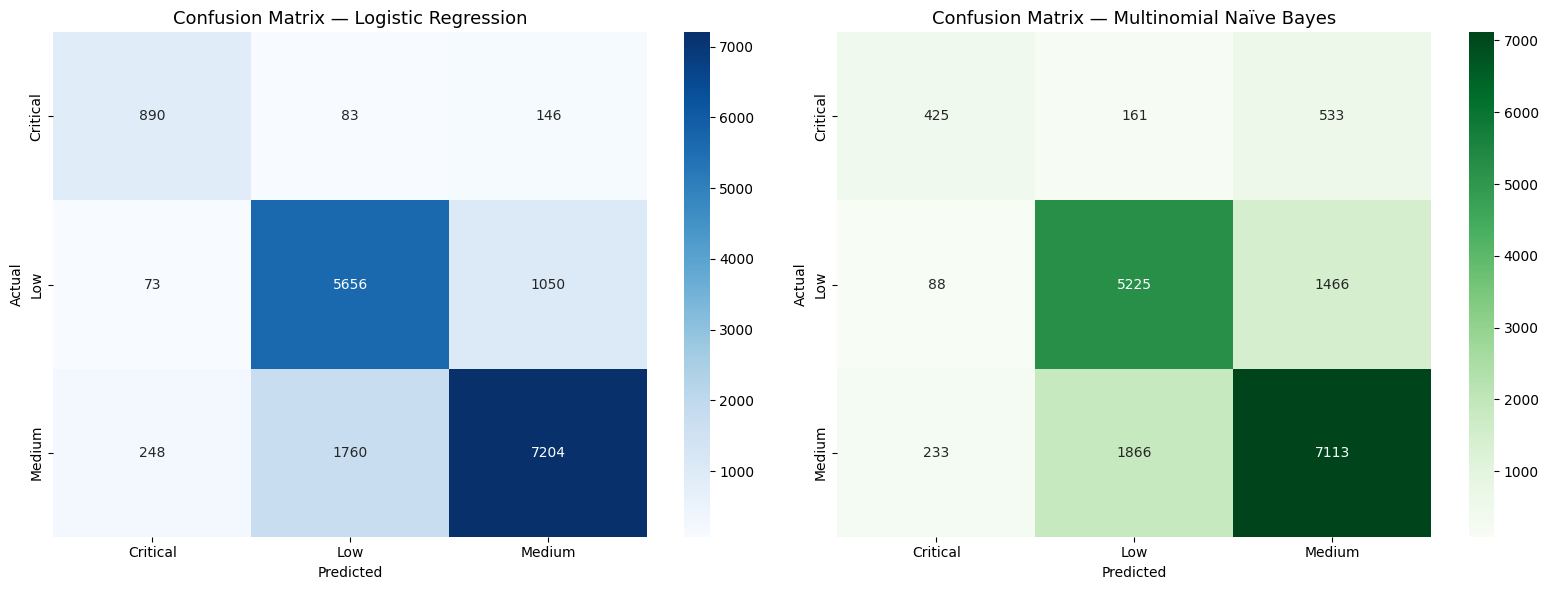

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_mnb = confusion_matrix(y_test, y_pred_mnb)

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
axes[0].set_title('Confusion Matrix — Logistic Regression', fontsize=13)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(cm_mnb, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[1])
axes[1].set_title('Confusion Matrix — Multinomial Naïve Bayes', fontsize=13)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('../reports/confusion_matrix_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

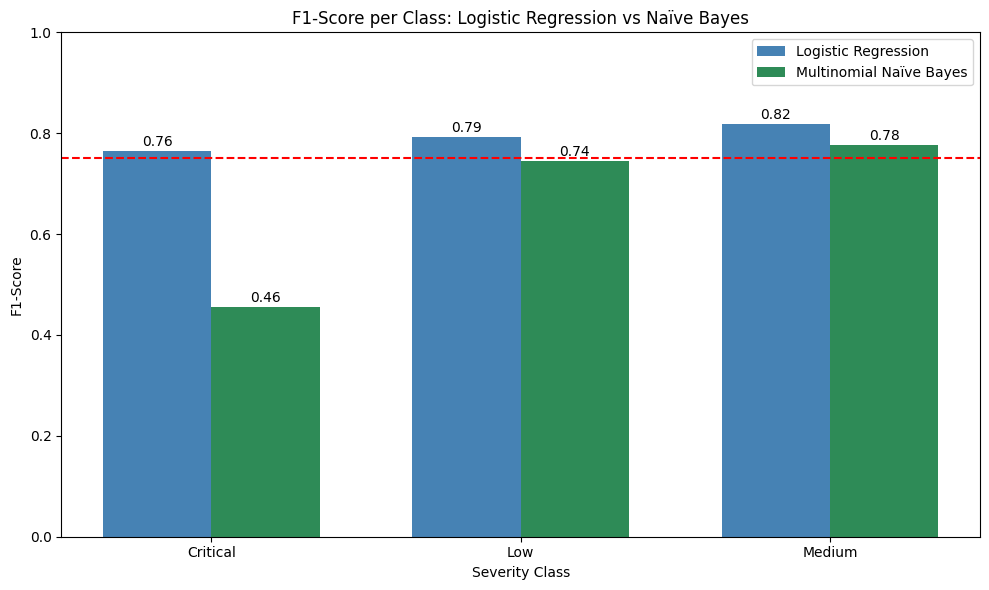

In [4]:
report_lr = classification_report(y_test, y_pred_lr, target_names=le.classes_, output_dict=True)
report_mnb = classification_report(y_test, y_pred_mnb, target_names=le.classes_, output_dict=True)

classes = le.classes_
f1_lr = [report_lr[c]['f1-score'] for c in classes]
f1_mnb = [report_mnb[c]['f1-score'] for c in classes]

x = np.arange(len(classes))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, f1_lr, width, label='Logistic Regression', color='steelblue')
bars2 = ax.bar(x + width/2, f1_mnb, width, label='Multinomial Naïve Bayes', color='seagreen')

ax.set_xlabel('Severity Class')
ax.set_ylabel('F1-Score')
ax.set_title('F1-Score per Class: Logistic Regression vs Naïve Bayes')
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.set_ylim(0, 1.0)
ax.legend()
ax.axhline(y=0.75, color='red', linestyle='--', label='Threshold 0.75')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('../reports/f1_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
print("=" * 55)
print("       Final Evaluation Summary")
print("=" * 55)
print(f"{'Metric':<30} {'LR':>10} {'MNB':>10}")
print("-" * 55)
print(f"{'Accuracy':<30} {accuracy_score(y_test, y_pred_lr)*100:>9.2f}% {accuracy_score(y_test, y_pred_mnb)*100:>9.2f}%")
print(f"{'F1 - Critical':<30} {report_lr['Critical']['f1-score']:>10.2f} {report_mnb['Critical']['f1-score']:>10.2f}")
print(f"{'F1 - Low':<30} {report_lr['Low']['f1-score']:>10.2f} {report_mnb['Low']['f1-score']:>10.2f}")
print(f"{'F1 - Medium':<30} {report_lr['Medium']['f1-score']:>10.2f} {report_mnb['Medium']['f1-score']:>10.2f}")
print(f"{'F1 Macro Average':<30} {report_lr['macro avg']['f1-score']:>10.2f} {report_mnb['macro avg']['f1-score']:>10.2f}")
print(f"{'F1 Weighted Average':<30} {report_lr['weighted avg']['f1-score']:>10.2f} {report_mnb['weighted avg']['f1-score']:>10.2f}")
print("-" * 55)
print(f"{'Best Model':<30} {'Logistic Regression':>20}")
print("=" * 55)

       Final Evaluation Summary
Metric                                 LR        MNB
-------------------------------------------------------
Accuracy                           80.36%     74.59%
F1 - Critical                        0.76       0.46
F1 - Low                             0.79       0.74
F1 - Medium                          0.82       0.78
F1 Macro Average                     0.79       0.66
F1 Weighted Average                  0.80       0.74
-------------------------------------------------------
Best Model                      Logistic Regression
